In [1]:
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import requests
import urllib
import subprocess
import torch
import tqdm
from shared import config

# Анализ и подготовка датасета

## Загрузка данных с Яндекс.Диска

In [2]:
# https://github.com/SecFathy/YandexDown/blob/main/YandexCLI.py

class YandexDiskDownloader:
    def __init__(self, link, download_location):
        self.link = link
        self.download_location = Path(download_location)

    def download(self):
        url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={urllib.parse.quote(self.link, safe='')}"
        response = requests.get(url)
        response.raise_for_status()
        download_url = response.json()["href"]
        file_name = urllib.parse.unquote(download_url.split("filename=")[1].split("&")[0])
        save_path = self.download_location / file_name
        self.download_location.mkdir(parents=True, exist_ok=True)
        with open(save_path, "wb") as f:
            r = requests.get(download_url, stream=True)
            for chunk in r.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
                    f.flush()
        print("Download complete.")
        return save_path

downloader = YandexDiskDownloader("https://disk.yandex.ru/d/h1SEmkqBro8Ffg", config.PROJECT_ROOT)
downloader.download()

Download complete.


PosixPath('/Users/dk/Desktop/ВШЭ/ВКР/HSE_VKR_DetectingSpeechDefects/data.tar.gz')

In [3]:
archive = config.PROJECT_ROOT / "data.tar.gz"
if archive.exists():
    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(["tar", "-xzf", str(archive), "-C", str(config.DATA_DIR)], check=True)
    print("Распаковка завершена.")
else:
    print("Файл data.tar.gz не найден.")

Распаковка завершена.


## Удаление дубликатов

Удаляются файлы с "(1)" в имени, если есть оригинал того же размера.

In [4]:
def delete_duplicates(directory_path):
    path = Path(directory_path)
    if not path.exists():
        print(f"Папка {directory_path} не найдена.")
        return
    print(f"Поиск дубликатов в {path.name}...")
    to_delete = []
    for f in path.iterdir():
        if not f.is_file():
            continue
        name = f.name
        if "(1)" not in name:
            continue
        parts = name.rsplit("(1)", 1)
        if len(parts) != 2:
            continue
        original_name = parts[0].rstrip() + parts[1].lstrip()
        original_path = path / original_name
        if original_path.is_file() and original_path.stat().st_size == f.stat().st_size:
            to_delete.append(f)
    for f in to_delete:
        f.unlink()
        print(f"  Удалён дубликат: {f.name}")
    if not to_delete:
        print(f"  Дубликатов не найдено.")

delete_duplicates(config.GOOD_DIR)
delete_duplicates(config.BAD_DIR)

Поиск дубликатов в good...
  Удалён дубликат: eu.7c595ed0-3958-43f3-a29d-3700a9e5c750__чсрлц(1).wav
  Удалён дубликат: eu.3d5af675-092a-4f3e-9265-bdc70bcb2c17__чстр(1).wav
  Удалён дубликат: eu.67fa1c0b-518e-4155-81a7-0cdcd9432887__сл(1).wav
  Удалён дубликат: eu.2b04a3f2-5397-4eea-a93c-ac145a0cbe78__рл(1).wav
  Удалён дубликат: eu.47035742-6d06-495b-811f-612d58d6d0e5__срл(1).wav
  Удалён дубликат: eu.10e21015-42c9-4ef8-a8c2-66d4057c5423__чстрш(1).wav
  Удалён дубликат: eu.1131c949-c891-44b0-b35f-78fa5be195ae__ст(1).wav
  Удалён дубликат: eu.a2480375-3559-4aab-a6da-86a76935afa8__стрш(1).wav
  Удалён дубликат: eu.468b4fa0-a72e-46e2-800c-b781dd918dc7__стрш(1).wav
  Удалён дубликат: eu.6056a741-3040-4376-9ad7-f59f83afbace__трлш(1).wav
Поиск дубликатов в bad...
  Дубликатов не найдено.


## Обнаружение и удаление пустых файлов с помощью VGGish

In [5]:
paths_good = sorted(config.GOOD_DIR.glob("*.wav"))
paths_bad = sorted(config.BAD_DIR.glob("*.wav"))
paths_all = [str(p) for p in paths_good] + [str(p) for p in paths_bad]

model = torch.hub.load("harritaylor/torchvggish", "vggish")
model.eval()

bad_files = []
for p in tqdm.tqdm(paths_all):
    try:
        model.forward(p)
    except Exception:
        bad_files.append(p)

empty_paths = bad_files
empty_set = set(empty_paths)
empty_mask = np.array([p in empty_set for p in paths_all])
print(f"Найдено пустых файлов: {len(empty_paths)}")
if empty_paths:
    for p in empty_paths:
        print(f"  {Path(p).name}")
        Path(p).unlink(missing_ok=True)
    print(f"Удалено файлов: {len(empty_paths)}")
else:
    print("Нет файлов для удаления.")

Using cache found in /Users/dk/.cache/torch/hub/harritaylor_torchvggish_master
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/resampy/filters.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()
100%|██████████| 2782/2782 [02:04<00:00, 22.37it/s]

Найдено пустых файлов: 6
  eu.27f03007-3b1e-4f98-9335-2cb45eb4f0d0__стлц.wav
  eu.429980b8-5979-41c8-847f-21739fcdfb5e__слц.wav
  eu.8803cf6d-1c43-4453-90b4-b8047e599323__тлщ.wav
  eu.904117a9-7971-4722-82cb-a2b9df69cd44__чсрлц.wav
  eu.933eed1a-8629-47bc-8304-7ec5ca65e6a2__стрл.wav
  eu.fc014530-281f-48a6-a8ed-90663a484f1a__трш.wav
Удалено файлов: 6


In [6]:
paths_good = sorted(config.GOOD_DIR.glob("*.wav"))
paths_bad = sorted(config.BAD_DIR.glob("*.wav"))
paths_all = [str(p) for p in paths_good] + [str(p) for p in paths_bad]
labels_all = [config.CLASS_GOOD] * len(paths_good) + [config.CLASS_BAD] * len(paths_bad)

print(f"Всего файлов: {len(paths_all)}")
print(f"good: {len(paths_good)}, bad: {len(paths_bad)}")

Всего файлов: 2776
good: 1875, bad: 901


## Извлечение контрольных букв скороговорок из имён файлов

Буквы берём из имени файла: часть после '__' и до расширения.

In [7]:
RUSSIAN_LOWER = frozenset(
    chr(c) for c in list(range(0x0430, 0x0450)) + [0x0451]
)


def extract_cyrillic_letters(text):
    normalized = unicodedata.normalize("NFC", text)
    return set(c.lower() for c in normalized if c.lower() in RUSSIAN_LOWER)


def fix_utf8_corrupted_on_windows(s):
    out = []
    i = 0
    while i < len(s):
        if i + 1 >= len(s):
            out.append(s[i])
            i += 1
            continue
        ord1, ord2 = ord(s[i]), ord(s[i + 1])
        if ord2 < 0x80 or ord2 > 0xBF:
            if ord1 == 0x0430 and ord2 == 0x041B:
                byte2 = 0xBB
            else:
                out.append(s[i])
                i += 1
                continue
        else:
            byte2 = ord2
        first_byte = 0xD1 if ord1 == 0x0431 else (0xD0 if ord1 == 0x0430 else None)
        if first_byte is not None:
            try:
                out.append(bytes([first_byte, byte2]).decode("utf-8"))
                i += 2
                continue
            except UnicodeDecodeError:
                pass
        out.append(s[i])
        i += 1
    return "".join(out)


def get_name_part_decoded(file_path):
    stem = Path(file_path).stem
    part = stem.split("__", 1)[1]
    part = fix_utf8_corrupted_on_windows(part)
    return part


all_letters = set()
file_letters = []
for p in paths_all:
    name_part = get_name_part_decoded(p)
    letters = extract_cyrillic_letters(name_part)
    if not letters:
        letters = extract_cyrillic_letters(Path(p).stem)
    all_letters.update(letters)
    file_letters.append(letters)

all_letters = sorted(all_letters)
print(f"Уникальных букв в названиях: {len(all_letters)} ({''.join(all_letters)})")

# Матрица признаков: по одному столбцу на букву, 0/1
letter_matrix = np.zeros((len(paths_all), len(all_letters)), dtype=np.int32)
for i, letters in enumerate(file_letters):
    for j, letter in enumerate(all_letters):
        if letter in letters:
            letter_matrix[i, j] = 1

print(f"Матрица букв: {letter_matrix.shape}")

Уникальных букв в названиях: 8 (лрстцчшщ)
Матрица букв: (2776, 8)


## Статистика датасета

In [11]:
sr = config.TARGET_SR
durations = []
for p in paths_all:
    y, _ = librosa.load(p, sr=sr, mono=True)
    durations.append(len(y) / sr)
durations = np.array(durations)

df_stats = pd.DataFrame({
    "класс": ["good", "bad"],
    "кол-во": [
        sum(1 for l in labels_all if l == config.CLASS_GOOD),
        sum(1 for l in labels_all if l == config.CLASS_BAD),
    ],
})
df_stats["доля %"] = (df_stats["кол-во"] / df_stats["кол-во"].sum() * 100).round(1)

print("Распределение по классам:")
print(df_stats.to_string(index=False))
print()
print("Длительность записей (сек):")
print(f"min: {durations.min():.2f}, max: {durations.max():.2f}, mean: {durations.mean():.2f}")
print(f"median: {np.median(durations):.2f},  std: {durations.std():.2f}")

Распределение по классам:
класс  кол-во  доля %
 good    1875    67.5
  bad     901    32.5

Длительность записей (сек):
min: 0.99, max: 68.66, mean: 10.36
median: 8.84,  std: 5.96


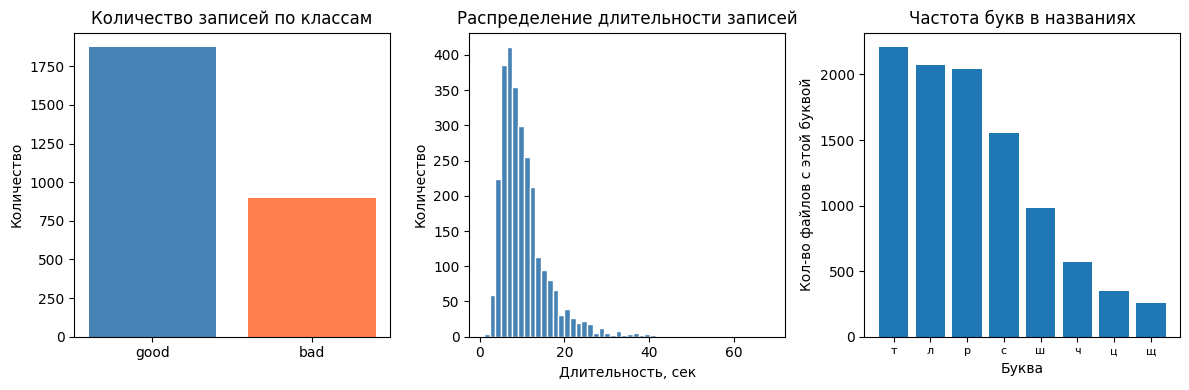

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(df_stats["класс"], df_stats["кол-во"], color=["steelblue", "coral"])
axes[0].set_title("Количество записей по классам")
axes[0].set_ylabel("Количество")

axes[1].hist(durations, bins=50, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Длительность, сек")
axes[1].set_ylabel("Количество")
axes[1].set_title("Распределение длительности записей")

letter_counts = letter_matrix.sum(axis=0)

pairs = zip(letter_counts, all_letters)
sorted_pairs = sorted(pairs, reverse=True)
sorted_counts, sorted_letters = zip(*sorted_pairs)
sorted_counts = list(sorted_counts)
sorted_letters = list(sorted_letters)

axes[2].bar(range(len(sorted_letters)), sorted_counts)
axes[2].set_xticks(range(len(sorted_letters)))
axes[2].set_xticklabels(sorted_letters, fontsize=8)
axes[2].set_xlabel("Буква")
axes[2].set_ylabel("Кол-во файлов с этой буквой")
axes[2].set_title("Частота букв в названиях")

plt.tight_layout()
plt.show()

## Сохранение CSV датасета

CSV сохраняется в `data/dataset.csv`: путь, метка класса, длительность и бинарные признаки по буквам.

In [13]:
csv_path = config.DATA_DIR / "dataset.csv"

filenames = []
for p in paths_all:
    path = Path(p)
    fn = path.name
    new_fn = fn[:fn.find('_')] + fn[fn.rfind('.'):]
    path.rename(path.with_name(new_fn))
    filenames.append(new_fn)

# filenames = [Path(p).name for p in paths_all]
dirnames = [Path(p).parent.name for p in paths_all]

df = pd.DataFrame({"filename": filenames, "dir": dirnames, "label": labels_all, "duration": durations})
for j, letter in enumerate(all_letters):
    df[letter] = letter_matrix[:, j]

df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"CSV сохранён: {csv_path}")
print(f"Строк: {len(df)}, столбцов: {len(df.columns)}")
df.sample(10)

CSV сохранён: /Users/dk/Desktop/ВШЭ/ВКР/HSE_VKR_DetectingSpeechDefects/data/dataset.csv
Строк: 2776, столбцов: 12


,filename,dir,label,duration,л,р,с,т,ц,ч,ш,щ
587,eu.52f75f93-f77a-4687-909f-746a174544df.wav,good,0,5.24,1,0,0,1,0,0,0,1
1848,eu.fcd82890-dcbb-487d-813a-0f572e5d7f87.wav,good,0,5.66,0,1,0,0,0,0,0,0
2414,eu.870ba9d3-44cc-4c24-967f-5efd83cbc9e6.wav,bad,1,15.08,1,1,0,1,0,0,1,0
704,eu.61f6ecd9-baf5-48c6-a36c-6628c3acb2f6.wav,good,0,12.08,1,1,0,1,1,1,0,0
1007,eu.907f72d6-126b-41c1-94a5-0988729c707d.wav,good,0,5.38,1,1,0,0,0,0,1,0
263,eu.26bf32f7-4eae-4899-ae95-ce4296173d7a.wav,good,0,6.38,1,1,0,0,0,0,1,0
27,eu.04a90a8b-e7f1-43a8-854f-5fa30306b1ac.wav,good,0,7.04,0,0,1,1,0,0,0,0
1203,eu.ab42868b-03c6-4833-9675-f35f03b3f5a9.wav,good,0,5.44,0,1,1,1,0,0,1,0
2042,eu.2c4a8980-5013-4036-b4b7-303db4323638.wav,bad,1,5.56,1,0,1,1,0,0,0,1
1309,eu.b972d86a-36f9-4399-a871-f9215e7a9c50.wav,good,0,7.34,1,1,1,1,0,0,1,0
